<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/METODO_PARA_DETERMINAR_CUANDO_DETENERSE_AL_GENERAR_NUEVOS_DATOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:purple;"> **METODO PARA DETERMINAR CUANDO DETENERSE AL GENERAR NUEVOS DATOS** </span>

**En los estudios de simulación, una de las preguntas más importantes es determinar cuántas observaciones o réplicas deben generarse para obtener estimaciones confiables de las medidas de desempeño del sistema. Si se generan muy pocos datos, los resultados pueden presentar una alta variabilidad y conducir a conclusiones incorrectas; por otro lado, generar demasiados datos implica un mayor costo computacional y un uso innecesario de recursos.**

**Para resolver este problema, se utilizan **criterios de paro** o **métodos de detención**, los cuales establecen una regla objetiva para decidir cuándo la información recolectada es suficiente. Generalmente, estos métodos se basan en el análisis estadístico de las salidas de la simulación, considerando medidas como la media muestral, la varianza y el ancho de los intervalos de confianza.**

**El objetivo principal es garantizar que las estimaciones obtenidas alcancen un nivel de precisión previamente especificado. De esta manera, la simulación puede detenerse cuando la incertidumbre asociada a los resultados sea lo suficientemente pequeña para cumplir con los requerimientos del estudio.**


# <span style="color:marron;"> *Seudocodigo* </span>

1. Elegir un valor aceptable $d$ para la derviación estándar del estimador.
2. Generar al menos $30$ datos.
3. Continuar generando hasta $k$ valores, tales que $\frac{s}{\sqrt k} < d$, donde $s$ es lña desviación estándar muestral de los $k$ valores.
4. La estimación de $\theta$ está dada por $\bar{X}=\sum_{i=1}^{k} \frac{x_i}{k}$





# <span style="color:blue;"> **ACTIVIDAD** </span>


* Estime $$\int_{0}^{1} exp(x^2) \,dx$$ por $MC$
* Genere al menos $100$ valores y deténgase cuando la desviación estándar de su estimador sea menor que $0.01$ y $0.001$

**FÓRMULAS RECURSIVAS**

con $\bar{X_0}=0$; $S^2_1=0$


$$\bar X_{j+1} = \bar X_j + \frac{X_{j+1}- \bar X_j}{j+1}$$


$$S^2_{j+1}= \left(1- \frac{1}{j}\right) S^2_j+ (j+1)(\bar X_{j+1}-\bar X_j)^2 $$

**ANALITICAMENTE**


*Solucion*

Se desea estimar la integral

$$
I=\int_0^1 e^{x^2}\,dx
$$

mediante el método de Monte Carlo, generando al menos \(100\) observaciones y deteniendo la simulación cuando la desviación estándar del estimador sea menor que \(0.01\) y \(0.001\).

1. **Transformación de la integral en una esperanza**

Sea

$$
U\sim U(0,1).
$$

Por la definición de esperanza de una variable aleatoria uniforme,

$$
E[g(U)]
=
\int_0^1 g(x)\,dx.
$$

Tomando

$$
g(x)=e^{x^2},
$$

se obtiene

$$
I
=
E[e^{U^2}].
$$

Por lo tanto, si se generan variables aleatorias independientes

$$
U_1,U_2,\ldots,U_n \sim U(0,1),
$$

y se define

$$
X_i=e^{U_i^2},
$$

entonces el estimador Monte Carlo de la integral es

$$
\hat I_n
=
\frac1n\sum_{i=1}^{n}X_i.
$$

2. **Valor exacto de la integral**

La integral no posee una primitiva elemental. Sin embargo,

$$
\int_0^1 e^{x^2}\,dx
=
\frac{\sqrt{\pi}}{2}\operatorname{erfi}(1),
$$

donde $\operatorname {erfi}$ es la función error imaginaria.

Numéricamente,

$$
I \approx 1.462651746.
$$

Este será el valor de referencia para comparar la estimación Monte Carlo.

3. **Media de la variable Monte Carlo**

La media de la variable aleatoria $(X=e^{U^2})$ es

$$
\mu
=
E[X]
=
\int_0^1 e^{x^2}\,dx
=
1.462651746.
$$

Por lo tanto,

$$
\boxed{\mu \approx 1.462651746}
$$

4. **Varianza teórica**

Para calcular la varianza se requiere primero obtener

$$
E[X^2].
$$

Como

$$
X=e^{U^2},
$$

entonces

$$
X^2=e^{2U^2}.
$$

Por lo tanto,

$$
E[X^2]
=
\int_0^1 e^{2x^2}\,dx.
$$

Usando nuevamente la función $(\operatorname{erfi})$,

$$
E[X^2]
=
\frac{\sqrt{\pi}}{2\sqrt2}
\operatorname{erfi}(\sqrt2).
$$

Numéricamente,

$$
E[X^2]
\approx 2.36445.
$$

La varianza es
$$
\operatorname{Var}(X)
=
E[X^2]-\mu^2.
$$

Sustituyendo valores,

$$
\operatorname{Var}(X)
=
2.36445-(1.462651746)^2.
$$

Por lo tanto,

$$
\operatorname{Var}(X)
\approx 0.22410.
$$

La desviación estándar es

$$
\sigma
=
\sqrt{\operatorname{Var}(X)}
\approx 0.4734.
$$

Así,

$$
\boxed{\sigma \approx 0.4734}
$$
5. **Desviación estándar del estimador Monte Carlo**

Por el Teorema Central del Límite,

$$
\operatorname{Var}(\hat I_n)
=
\frac{\sigma^2}{n}.
$$

Por lo tanto,

$$
SD(\hat I_n)
=
\frac{\sigma}{\sqrt n}.
$$

Sustituyendo $(\sigma\approx0.4734)$,

$$
SD(\hat I_n)
=
\frac{0.4734}{\sqrt n}.
$$

El criterio de paro utilizado es

$$
\frac{s}{\sqrt n}<d,
$$

donde $s$ es la desviación estándar muestral y $d$ es la precisión deseada.

Analíticamente se aproxima

$$
s\approx\sigma.
$$

6. **Caso $d=0.01$**

Se requiere que

$$
\frac{0.4734}{\sqrt n}<0.01.
$$

Multiplicando ambos lados por $\sqrt n$,

$$
0.4734<0.01\sqrt n.
$$
Dividiendo entre $0.01$,

$$
47.34<\sqrt n.
$$

Elevando al cuadrado,

$$
n>2241.08.
$$

Por lo tanto,

$$
\boxed{n\approx2242}.
$$

Es decir, se necesitan aproximadamente $2242$ observaciones para alcanzar una desviación estándar menor que $0.01$.

7. **Caso $d=0.001$**

Ahora se requiere que

$$
\frac{0.4734}{\sqrt n}<0.001.
$$

Multiplicando ambos lados por $\sqrt n$,

$$
0.4734<0.001\sqrt n.
$$

Dividiendo entre $0.001$,

$$
473.4<\sqrt n.
$$

Elevando al cuadrado,

$$
$$

Por lo tanto,

$$
\boxed{n\approx224108}.
$$

Es decir, se requieren aproximadamente $224108$ observaciones para alcanzar una desviación estándar menor que $0.001$.

8. **Aplicación de las fórmulas recursivas**

Al generar los datos

$$
X_j=e^{U_j^2},
$$

la media muestral se actualiza mediante

$$
\bar X_{j+1}
=
\bar X_j
+
\frac{X_{j+1}-\bar X_j}{j+1}.
$$

La varianza muestral se actualiza mediante

$$
S^2_{j+1}
=
\left(1-\frac1j\right)S_j^2
+
(j+1)(\bar X_{j+1}-\bar X_j)^2.
$$

Después de cada nueva observación se verifica la condición

$$
\frac{S_j}{\sqrt j}<d.
$$

Cuando esta desigualdad se cumple, la simulación se detiene.

**Conclusión**

La integral

$$
\int_0^1 e^{x^2}\,dx
$$

puede estimarse mediante el método Monte Carlo utilizando

$$
X=e^{U^2},
\qquad
U\sim U(0,1).
$$

El valor exacto de la integral es

$$
\boxed{I\approx1.462651746}.
$$

La desviación estándar teórica de la variable utilizada en la simulación es

$$
\boxed{\sigma\approx0.4734}.
$$

Por lo tanto, el número aproximado de observaciones necesarias para satisfacer el criterio de paro es

$$
\boxed{n\approx2242 \quad (d=0.01)}
$$

y

$$
\boxed{n\approx224108 \quad (d=0.001)}.
$$

Estos tamaños muestrales representan el número esperado de observaciones que deben generarse antes de que el algoritmo se detenga.



In [4]:
#bibliotecas
import random
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


Procedemos con:




In [6]:

def monte_carlo(d, minimo=100):

    # Inicialización
    media = 0.0      # X̄₀
    s2 = 0.0         # S²₁
    k = 0            # contador de observaciones

    while True:

        # Generar U ~ Uniforme(0,1)
        u = random.random()


        # Transformación:
        # X = exp(U²)

        x = math.exp(u**2)

        k += 1


        media_anterior = media


        # Fórmula recursiva de la media
        #
        # X̄(j+1)=X̄(j)+(X(j+1)-X̄(j))/(j+1)

        media = media + (x - media) / k

        # Fórmula recursiva de la varianza
        #
        # S²(j+1)= (1-1/j)S²(j)
        #          +(j+1)(X̄(j+1)-X̄(j))²

        if k >= 2:
            s2 = (1 - 1/(k-1))*s2 \
                 + k*(media - media_anterior)**2

        # Desviación estándar muestral
        s = math.sqrt(s2)

        # Error estándar del estimador
        error = s / math.sqrt(k)


        # Criterio de paro

        if k >= minimo and error < d:
            break

    return media, s, error, k


In [7]:


# EXPERIMENTO 1
# d = 0.01


estimacion1, s1, error1, n1 = monte_carlo(0.01)

print("="*50)
print("RESULTADOS PARA d = 0.01")
print("="*50)
print(f"Estimación           = {estimacion1:.8f}")
print(f"Desviación estándar  = {s1:.8f}")
print(f"Error estándar       = {error1:.8f}")
print(f"Número de datos      = {n1}")


RESULTADOS PARA d = 0.01
Estimación           = 1.45999052
Desviación estándar  = 0.47383644
Error estándar       = 0.00999824
Número de datos      = 2246


In [8]:

# EXPERIMENTO 2
# d = 0.001
estimacion2, s2, error2, n2 = monte_carlo(0.001)

print("\n")
print("="*50)
print("RESULTADOS PARA d = 0.001")
print("="*50)
print(f"Estimación           = {estimacion2:.8f}")
print(f"Desviación estándar  = {s2:.8f}")
print(f"Error estándar       = {error2:.8f}")
print(f"Número de datos      = {n2}")




RESULTADOS PARA d = 0.001
Estimación           = 1.46181596
Desviación estándar  = 0.47382150
Error estándar       = 0.00100000
Número de datos      = 224508


In [9]:

# Valor real de referencia
valor_real = 1.462651746

print("\n")
print("="*50)
print("COMPARACIÓN")
print("="*50)
print(f"Valor real aproximado = {valor_real:.8f}")
print(f"Error absoluto (d=0.01)  = {abs(estimacion1-valor_real):.8f}")
print(f"Error absoluto (d=0.001) = {abs(estimacion2-valor_real):.8f}")



COMPARACIÓN
Valor real aproximado = 1.46265175
Error absoluto (d=0.01)  = 0.00266123
Error absoluto (d=0.001) = 0.00083579


**Como se puede ver en el codigo:**

1 Generamos valores $U_i \sim U(0,1)$.
    
2 Calculamos
    $$
    X_i = e^{U_i^2}.
    $$
    
3 Actualizamos la media usando la fórmula recursiva:



$$    \bar X_{j+1}
    =
    \bar X_j
    +
    \frac{X_{j+1}-\bar{X}_j}{j+1}.$$
    
4 Actualizamos la varianza usando la fórmula dada en el enunciado.
    
5 Calculamos el error estándar:
    $$
    \frac{s}{\sqrt{k}}.
    $$
    
6 Se detiene cuando:
    $$
    k \geq 100
    \qquad \text{y} \qquad
    \frac{s}{\sqrt{k}} < d.
    $$
    
7 Se repite el procedimiento para
    $$
    d = 0.01
    \qquad \text{y} \qquad
    d = 0.001.
    $$



In [2]:

# Función para estimar la integral por Monte Carlo, utilizando las fórmulas recursivas

def monte_carlo_integral(d):

    media = 0.0   # Media inicial X̄0
    s2 = 0.0      # Varianza inicial S²1
    k = 0    # Contador de simulaciones

    # Listas para almacenar los valores para la gráfica
    iteraciones = []
    medias = []
    errores = [] # Adding for completeness, though not strictly needed for this error

    while True:

        u = random.random()  # Paso 1: generar U ~ Uniforme(0,1)
        x = math.exp(u**2)  # Paso 2: calcular Xi = exp(U²)
        k += 1          # Aumentar contador
        media_anterior = media        # Guardar media anterior

        media = media + (x - media) / k    # Paso 3: actualizar media recursivamente
        if k >= 2:  # Paso 4: actualizar varianza recursiva-

            s2 = (1 - 1/(k-1))*s2 \
                 + k*(media - media_anterior)**2


        s = math.sqrt(s2)  # Desviación estándar muestral


        error = s / math.sqrt(k)  # Error estándar del estimador

        # Almacenar valores para la gráfica
        iteraciones.append(k)
        medias.append(media)
        errores.append(error)

        if k >= 100 and error < d:  # Paso 5: criterio de paro
            break

    return media, s, error, k, iteraciones, medias, errores

*Ejecutación para $d=0.01$*

In [3]:
estimacion, s, error, n, iteraciones, medias, errores = monte_carlo_integral(0.01)

print("RESULTADOS")
print("Estimación =", estimacion)
print("Desv. estándar =", s)
print("Error estándar =", error)
print("Número de simulaciones =", n)

RESULTADOS
Estimación = 1.4535321797333256
Desv. estándar = 0.4637186964323371
Error estándar = 0.009996166305587919
Número de simulaciones = 2152


Al ejecutar el programa, observamos que para $d = 0.001$ se necesitan muchas más simulaciones que para $d = 0.01$. Esto ocurre porque el error estándar disminuye aproximadamente como
$$
\frac{1}{\sqrt{k}},
$$
por lo que aumentar la precisión requiere incrementar considerablemente el tamaño de muestra. Aun así, ambas estimaciones convergen a un valor cercano a

$$
\int_0^1 e^{x^2}\,dx \approx 1.462651746,
$$

confirmando la validez del método Monte Carlo y de las fórmulas recursivas empleadas.

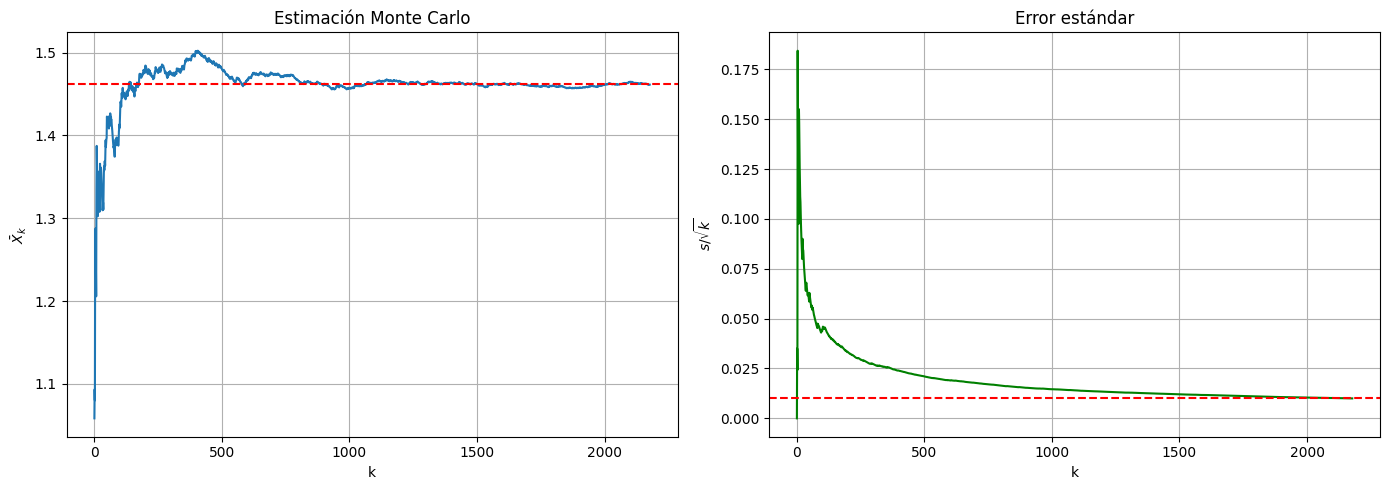

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Convergencia

ax[0].plot(iteraciones, medias)

ax[0].axhline(valor_real,
              color='red',
              linestyle='--')

ax[0].set_title("Estimación Monte Carlo")
ax[0].set_xlabel("k")
ax[0].set_ylabel(r'$\bar{X}_k$')
ax[0].grid(True)

# Error estándar

ax[1].plot(iteraciones,
           errores,
           color='green')

ax[1].axhline(0.01, #El uso directo de 0.01 como 'd' se pasó como 0.01 a monte_carlo_integral.
              color='red',
              linestyle='--')

ax[1].set_title("Error estándar")
ax[1].set_xlabel("k")
ax[1].set_ylabel(r'$s/\sqrt{k}$'
)
ax[1].grid(True)

plt.tight_layout()
plt.show()


Estas gráficas muestran la convergencia de su estimación de Monte Carlo y el comportamiento del error estándar:

* **Gráfica Izquierda (Estimación Monte Carlo):** Esta gráfica ilustra cómo el valor estimado de la integral (la línea azul) converge hacia el valor real (la línea roja discontinua) a medida que el número de simulaciones ($k$) aumenta. Se puede observar una reducción significativa en las fluctuaciones iniciales a medida que se acumulan más datos, lo que demuestra el principio de la convergencia de Monte Carlo.
* **Gráfica Derecha (Error estándar):** Esta gráfica presenta el error estándar del estimador (la línea verde) como función del número de simulaciones. La línea roja discontinua representa el umbral de error objetivo (en este caso, $d = 0.01$). Como se esperaba, el error estándar disminuye a medida que $k$ aumenta, y finalmente cae por debajo del umbral especificado, lo cual activa el criterio de parada de la simulación. La relación de decrecimiento del error estándar es aproximadamente de la forma $\frac{s}{\sqrt{k}}$.


En resumen, estas visualizaciones demuestran claramente la eficacia del método de Monte Carlo para estimar integrales y cómo el criterio de parada asegura la precisión deseada en la estimación al alcanzar un error estándar objetivo.



### Cálculo del Intervalo de Confianza del 95%

In [5]:

# Para un nivel de confianza del 95%, el valor crítico Z es aproximadamente 1.96
Z_critical = 1.96

# Re-ejecutar las simulaciones para asegurar que las variables estén definidas
estimacion1, s1, error1, n1 = monte_carlo(0.01)
estimacion2, s2, error2, n2 = monte_carlo(0.001)

# Intervalo de confianza para d = 0.01
ci_lower_01 = estimacion1 - Z_critical * error1
ci_upper_01 = estimacion1 + Z_critical * error1

# Intervalo de confianza para d = 0.001
ci_lower_001 = estimacion2 - Z_critical * error2
ci_upper_001 = estimacion2 + Z_critical * error2

print("="*50)
print("INTERVALOS DE CONFIANZA DEL 95%")
print("="*50)
print(f"Intervalo para d=0.01: [{ci_lower_01:.8f}, {ci_upper_01:.8f}]")
print(f"Intervalo para d=0.001: [{ci_lower_001:.8f}, {ci_upper_001:.8f}]")

INTERVALOS DE CONFIANZA DEL 95%
Intervalo para d=0.01: [1.45931106, 1.49850664]
Intervalo para d=0.001: [1.46248076, 1.46640074]
